In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import integrate
import numpy as np
import os
import numpy as np
from scipy.stats import shapiro,mannwhitneyu,levene


In [14]:
fileName = r"logs\query_timing1.csv"
df = pd.read_csv(fileName)

Rows in source: 710
Rows with all key fields: 710
Rows excluded due to non-positive energy: 5
Rows used for plots: 705


,count,mean,std,min,25%,50%,75%,max
total_elapsed_sec,705.0,134.638581,114.016018,5.766505,49.079116,117.287114,193.785688,691.319924
rapl_package_j,705.0,1154.891377,916.646518,39.679871,364.670715,947.299683,1646.058533,5302.179321
rapl_core_j,705.0,1008.924038,799.959807,33.078491,313.344177,829.562866,1432.743652,4624.986816


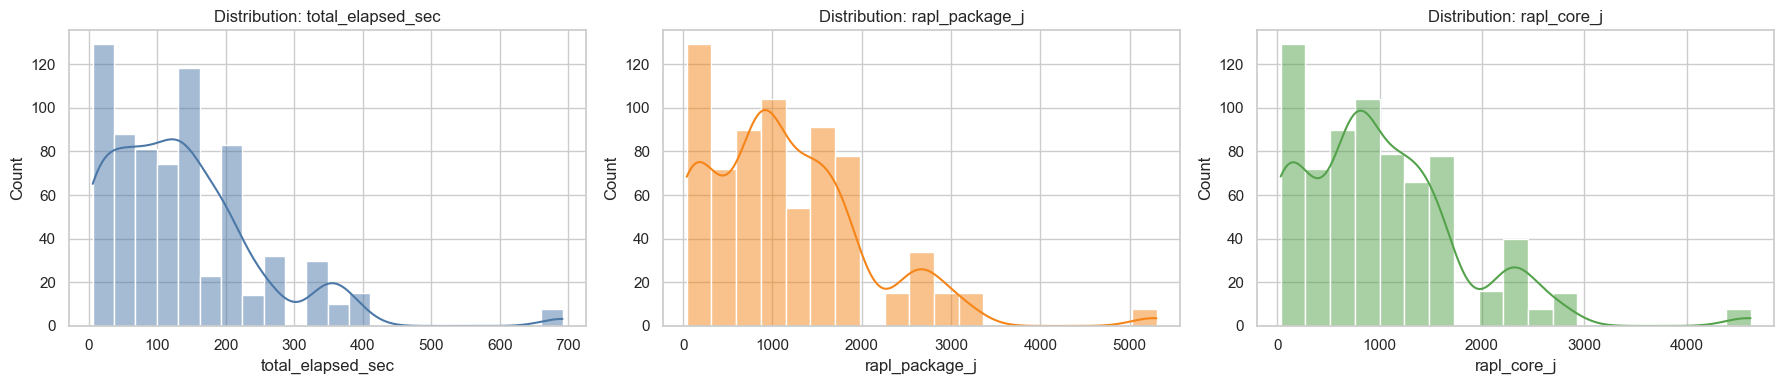

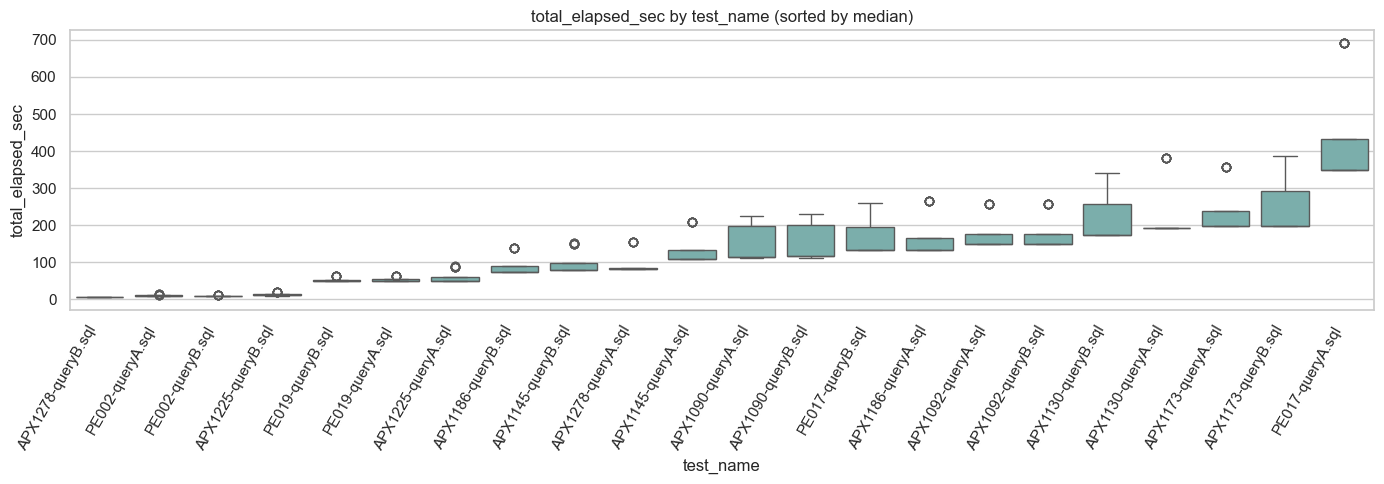

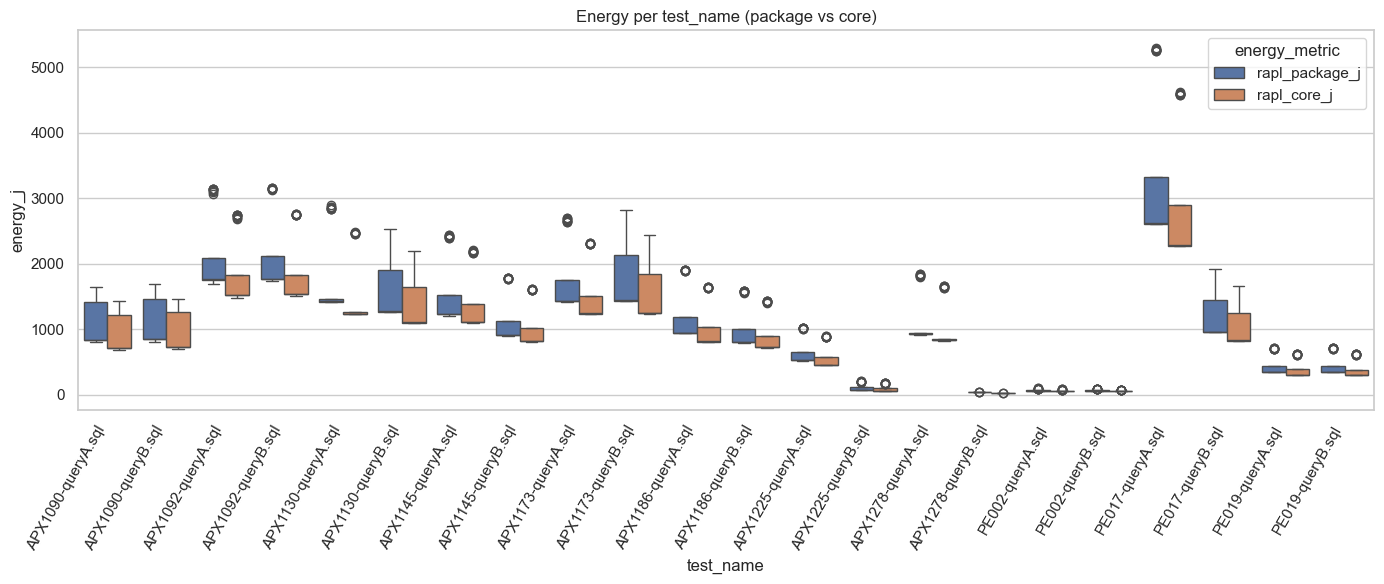

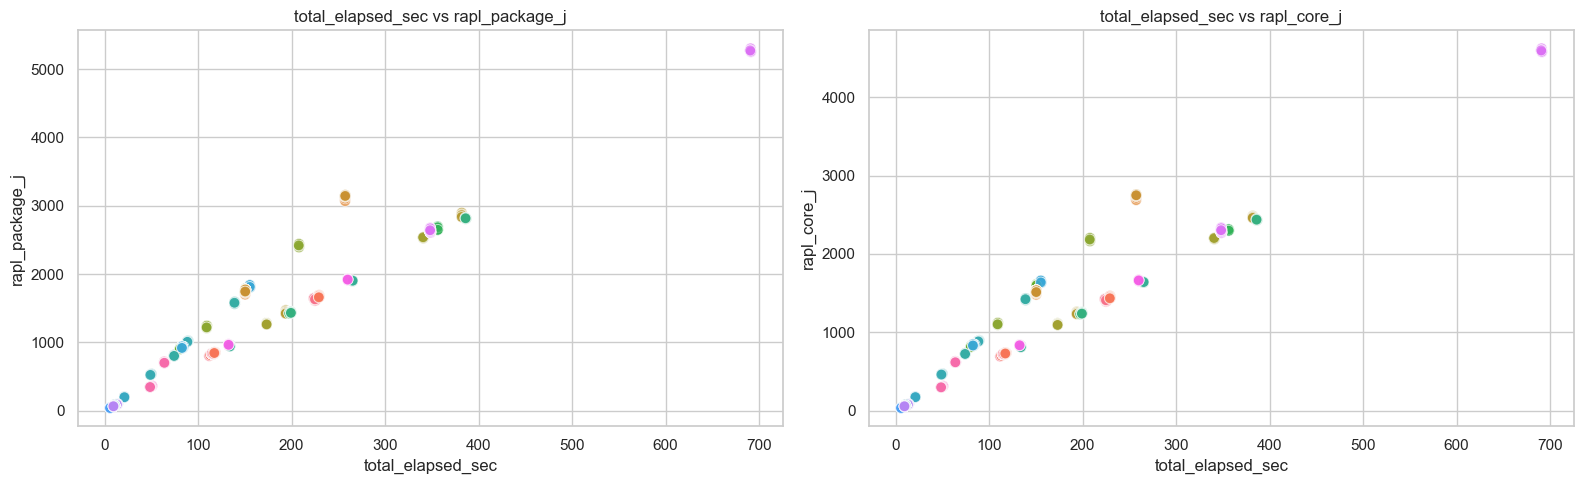

,test_name,total_elapsed_sec,rapl_package_j,rapl_core_j
603,PE017-queryB.sql,132.700978,-261176.897461,836.341919
311,APX1130-queryB.sql,173.319078,-260870.744019,1102.745178
124,APX1130-queryA.sql,381.871872,-259255.961060,2479.688416
396,APX1173-queryB.sql,199.428076,1441.785217,-260896.963074
156,APX1278-queryA.sql,155.122742,1817.472290,-260502.790710


In [15]:
# Focus on the columns relevant for exploratory analysis
cols = ["test_name", "total_elapsed_sec", "rapl_package_j", "rapl_core_j"]
edf = df[cols].copy()

# Ensure numeric columns are clean numeric values
num_cols = ["total_elapsed_sec", "rapl_package_j", "rapl_core_j"]
for c in num_cols:
    edf[c] = pd.to_numeric(edf[c], errors="coerce")

# Keep rows with complete values in the selected columns
edf = edf.dropna(subset=cols).copy()

# Keep only physically plausible positive energy readings for visual analysis
invalid_energy_mask = (edf["rapl_package_j"] <= 0) | (edf["rapl_core_j"] <= 0)
edf_valid = edf.loc[~invalid_energy_mask].copy()

print(f"Rows in source: {len(df):,}")
print(f"Rows with all key fields: {len(edf):,}")
print(f"Rows excluded due to non-positive energy: {invalid_energy_mask.sum():,}")
print(f"Rows used for plots: {len(edf_valid):,}")

display(edf_valid[num_cols].describe().T)

sns.set_theme(style="whitegrid")

# 1) Distribution of runtime and energy
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(edf_valid["total_elapsed_sec"], kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribution: total_elapsed_sec")

sns.histplot(edf_valid["rapl_package_j"], kde=True, ax=axes[1], color="#F58518")
axes[1].set_title("Distribution: rapl_package_j")

sns.histplot(edf_valid["rapl_core_j"], kde=True, ax=axes[2], color="#54A24B")
axes[2].set_title("Distribution: rapl_core_j")
plt.tight_layout()
plt.show()

# 2) Runtime variation by test
plt.figure(figsize=(14, 5))
order = edf_valid.groupby("test_name")["total_elapsed_sec"].median().sort_values().index
sns.boxplot(data=edf_valid, x="test_name", y="total_elapsed_sec", order=order, color="#72B7B2")
plt.xticks(rotation=60, ha="right")
plt.title("total_elapsed_sec by test_name (sorted by median)")
plt.tight_layout()
plt.show()

# 3) Energy variation by test for package/core
energy_long = edf_valid.melt(
    id_vars="test_name",
    value_vars=["rapl_package_j", "rapl_core_j"],
    var_name="energy_metric",
    value_name="energy_j"
 )

plt.figure(figsize=(14, 6))
sns.boxplot(data=energy_long, x="test_name", y="energy_j", hue="energy_metric")
plt.xticks(rotation=60, ha="right")
plt.title("Energy per test_name (package vs core)")
plt.tight_layout()
plt.show()

# 4) Relationship between elapsed time and energy
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
sns.scatterplot(
    data=edf_valid,
    x="total_elapsed_sec",
    y="rapl_package_j",
    hue="test_name",
    alpha=0.7,
    s=60,
    ax=axes[0],
    legend=False
 )
axes[0].set_title("total_elapsed_sec vs rapl_package_j")

sns.scatterplot(
    data=edf_valid,
    x="total_elapsed_sec",
    y="rapl_core_j",
    hue="test_name",
    alpha=0.7,
    s=60,
    ax=axes[1],
    legend=False
 )
axes[1].set_title("total_elapsed_sec vs rapl_core_j")

plt.tight_layout()
plt.show()

# Show suspicious rows separately for inspection
display(edf.loc[invalid_energy_mask, cols].sort_values("rapl_package_j").head(10))

Cluster centers (interpreted as typical slope/band):


,group_label,pkg_slope_j_per_sec,core_slope_j_per_sec
0,low,-10.599107,-9.309868
1,mid,9.524111,8.383703
2,high,23.981923,21.579673


Per-query fitted line quality and slope:


,test_name,metric,group_label,slope_j_per_sec,intercept_j,r2,n
31,APX1278-queryB.sql,rapl_core_j,low,-9.309868,87.945680,0.225487,33
21,APX1186-queryA.sql,rapl_core_j,mid,6.277535,-25.037111,0.999895,32
1,APX1090-queryA.sql,rapl_core_j,mid,6.330317,-8.653566,0.998958,34
19,APX1173-queryB.sql,rapl_core_j,mid,6.375751,-24.670947,0.999894,31
3,APX1090-queryB.sql,rapl_core_j,mid,6.385729,-15.004583,0.999515,34
35,PE002-queryB.sql,rapl_core_j,mid,6.395327,-5.628749,0.997706,32
33,PE002-queryA.sql,rapl_core_j,mid,6.447034,-6.034765,0.997963,32
11,APX1130-queryB.sql,rapl_core_j,mid,6.516868,-25.043549,0.999887,31
39,PE017-queryB.sql,rapl_core_j,mid,6.529588,-37.081710,0.999755,31
9,APX1130-queryA.sql,rapl_core_j,mid,6.540464,-27.094113,0.999715,31


A/B comparison (% difference of B relative to A):


,query_family,elapsed_pct_B_vs_A,pkg_energy_pct_B_vs_A,core_energy_pct_B_vs_A,pkg_intensity_pct_B_vs_A,core_intensity_pct_B_vs_A
7,APX1278,-94.099468,-96.412592,-96.689065,-38.855201,-43.555974
6,APX1225,-77.593842,-83.596132,-83.970806,-29.608319,-31.485652
9,PE017,-61.849750,-63.301690,-63.594353,-3.921733,-4.713008
5,APX1186,-45.667381,-15.409545,-11.643697,55.089412,62.014753
3,APX1145,-26.684876,-26.254737,-26.362482,0.405466,0.252725
2,APX1130,-8.352330,-8.852140,-8.702859,-0.525530,-0.397525
8,PE002,-1.358146,-1.614381,-1.703219,-0.222791,-0.303751
10,PE019,-0.569581,-0.069601,-0.112327,0.376849,0.334142
1,APX1092,0.005236,0.691750,0.656719,0.667554,0.632370
0,APX1090,2.035454,2.286632,2.253107,0.185864,0.151648


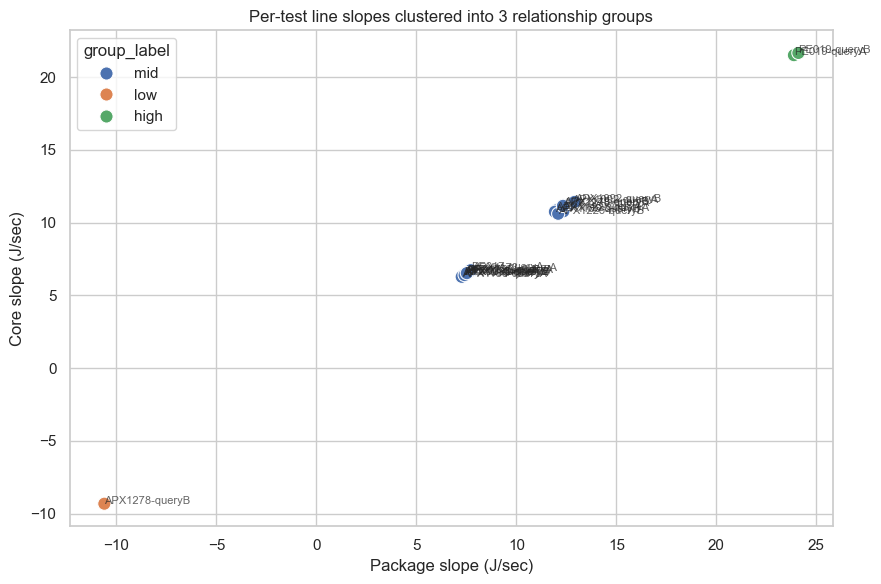

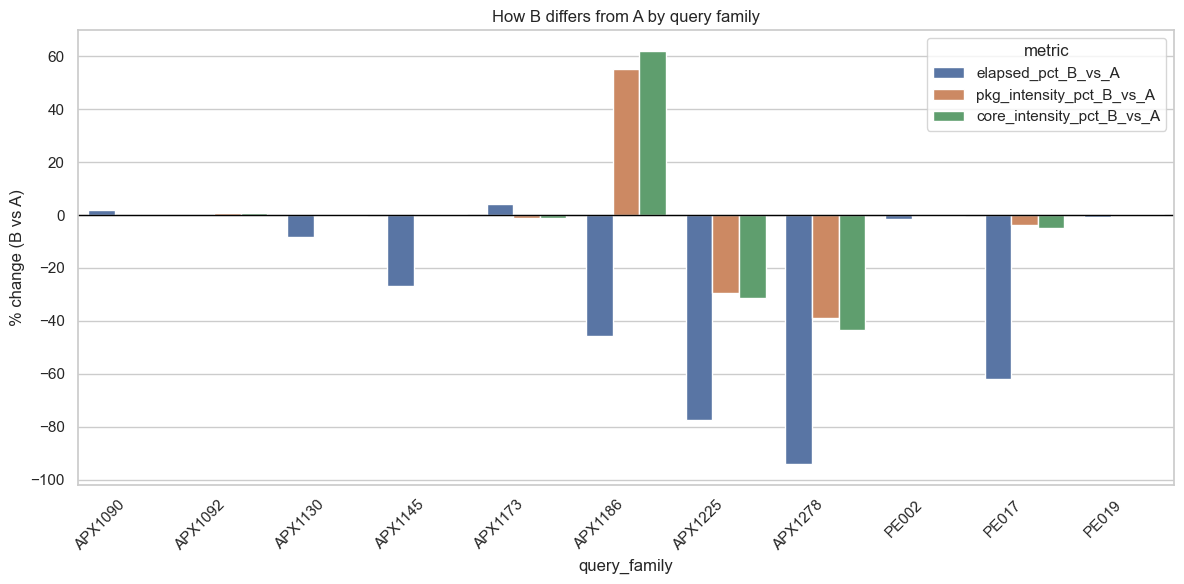

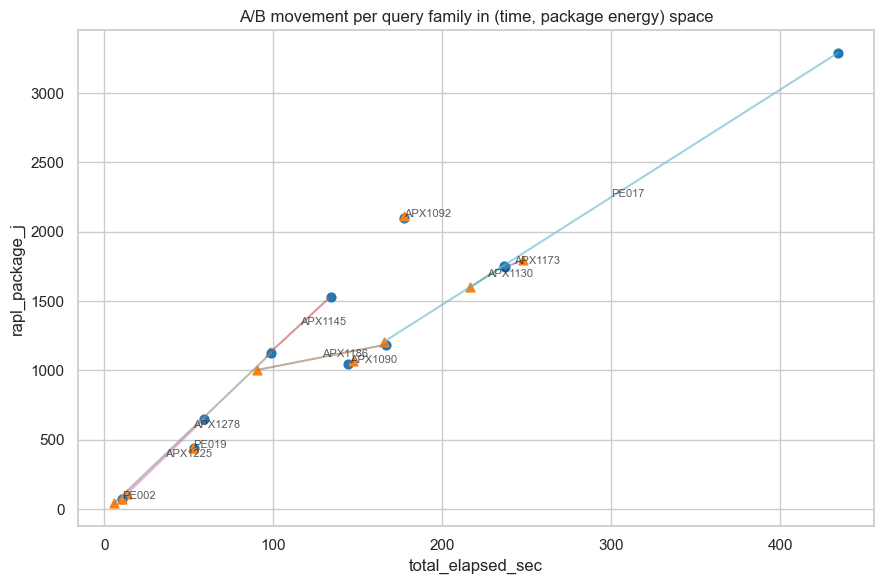

In [16]:
# Expanded analysis of scatter relationships and A/B query alternatives
from sklearn.cluster import KMeans

adf = edf_valid.copy()

# Parse query family and alternative (A/B) from test_name
parsed = adf["test_name"].str.extract(r"^(.*)-query([AB])\.sql$")
adf["query_family"] = parsed[0]
adf["variant"] = parsed[1]

# Intensity metrics: energy consumed per second of elapsed runtime
adf["pkg_j_per_sec"] = adf["rapl_package_j"] / adf["total_elapsed_sec"]
adf["core_j_per_sec"] = adf["rapl_core_j"] / adf["total_elapsed_sec"]

# Per test_name linear relationship (rapl ~ time): slope/intercept/R^2
line_rows = []
for name, g in adf.groupby("test_name"):
    if len(g) < 3:
        continue
    x = g["total_elapsed_sec"].to_numpy()
    for metric in ["rapl_package_j", "rapl_core_j"]:
        y = g[metric].to_numpy()
        slope, intercept = np.polyfit(x, y, 1)
        y_hat = slope * x + intercept
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = np.nan if ss_tot == 0 else 1 - (ss_res / ss_tot)
        line_rows.append({
            "test_name": name,
            "metric": metric,
            "n": len(g),
            "slope_j_per_sec": slope,
            "intercept_j": intercept,
            "r2": r2,
            "mean_time_sec": g["total_elapsed_sec"].mean(),
            "mean_energy_j": g[metric].mean()
        })

line_df = pd.DataFrame(line_rows)

# Build one row per test_name for clustering line behavior
wide = line_df.pivot(index="test_name", columns="metric", values="slope_j_per_sec").reset_index()
wide.columns.name = None
wide = wide.rename(columns={
    "rapl_package_j": "pkg_slope",
    "rapl_core_j": "core_slope"
})

# Cluster slopes into 3 groups to match the visible bands
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
wide["line_group"] = kmeans.fit_predict(wide[["pkg_slope", "core_slope"]])

# Re-label groups as low/mid/high by package slope
centers = pd.DataFrame(kmeans.cluster_centers_, columns=["pkg_slope", "core_slope"])
centers["line_group"] = centers.index
centers = centers.sort_values("pkg_slope").reset_index(drop=True)
centers["group_label"] = ["low", "mid", "high"]
group_map = dict(zip(centers["line_group"], centers["group_label"]))
wide["group_label"] = wide["line_group"].map(group_map)

line_df = line_df.merge(wide[["test_name", "group_label"]], on="test_name", how="left")
adf = adf.merge(wide[["test_name", "group_label"]], on="test_name", how="left")

print("Cluster centers (interpreted as typical slope/band):")
display(
    centers[["group_label", "pkg_slope", "core_slope"]].rename(
        columns={"pkg_slope": "pkg_slope_j_per_sec", "core_slope": "core_slope_j_per_sec"}
    )
)

print("Per-query fitted line quality and slope:")
display(
    line_df.sort_values(["metric", "slope_j_per_sec"])[
        ["test_name", "metric", "group_label", "slope_j_per_sec", "intercept_j", "r2", "n"]
    ]
)

# A/B comparison at query family level
ab = (
    adf.groupby(["query_family", "variant"], dropna=False)[
        ["total_elapsed_sec", "rapl_package_j", "rapl_core_j", "pkg_j_per_sec", "core_j_per_sec"]
    ]
    .mean()
    .reset_index()
    .pivot(index="query_family", columns="variant")
)

# Flatten multi-index columns
ab.columns = [f"{m}_{v}" for m, v in ab.columns]
ab = ab.reset_index()

# Keep only families where both A and B exist
needed = ["total_elapsed_sec_A", "total_elapsed_sec_B"]
ab = ab.dropna(subset=needed).copy()

ab["elapsed_pct_B_vs_A"] = 100 * (ab["total_elapsed_sec_B"] - ab["total_elapsed_sec_A"]) / ab["total_elapsed_sec_A"]
ab["pkg_energy_pct_B_vs_A"] = 100 * (ab["rapl_package_j_B"] - ab["rapl_package_j_A"]) / ab["rapl_package_j_A"]
ab["core_energy_pct_B_vs_A"] = 100 * (ab["rapl_core_j_B"] - ab["rapl_core_j_A"]) / ab["rapl_core_j_A"]
ab["pkg_intensity_pct_B_vs_A"] = 100 * (ab["pkg_j_per_sec_B"] - ab["pkg_j_per_sec_A"]) / ab["pkg_j_per_sec_A"]
ab["core_intensity_pct_B_vs_A"] = 100 * (ab["core_j_per_sec_B"] - ab["core_j_per_sec_A"]) / ab["core_j_per_sec_A"]

print("A/B comparison (% difference of B relative to A):")
display(
    ab[[
        "query_family",
        "elapsed_pct_B_vs_A",
        "pkg_energy_pct_B_vs_A",
        "core_energy_pct_B_vs_A",
        "pkg_intensity_pct_B_vs_A",
        "core_intensity_pct_B_vs_A"
    ]].sort_values("elapsed_pct_B_vs_A")
)

# Visual 1: scatter with inferred group labels (the three relationship bands)
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=wide,
    x="pkg_slope",
    y="core_slope",
    hue="group_label",
    s=90
 )
for _, r in wide.iterrows():
    plt.text(r["pkg_slope"], r["core_slope"], r["test_name"].replace('.sql', ''), fontsize=8, alpha=0.7)
plt.title("Per-test line slopes clustered into 3 relationship groups")
plt.xlabel("Package slope (J/sec)")
plt.ylabel("Core slope (J/sec)")
plt.tight_layout()
plt.show()

# Visual 2: A vs B runtime and package/core energy intensity comparison
ab_long = ab.melt(
    id_vars="query_family",
    value_vars=[
        "elapsed_pct_B_vs_A",
        "pkg_intensity_pct_B_vs_A",
        "core_intensity_pct_B_vs_A"
    ],
    var_name="metric",
    value_name="pct_diff_B_vs_A"
 )

plt.figure(figsize=(12, 6))
sns.barplot(data=ab_long, x="query_family", y="pct_diff_B_vs_A", hue="metric")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("% change (B vs A)")
plt.title("How B differs from A by query family")
plt.tight_layout()
plt.show()

# Visual 3: direct A/B pairing in original scatter space
pair_plot_df = adf.groupby(["query_family", "variant"])[["total_elapsed_sec", "rapl_package_j"]].mean().reset_index()
pair_pivot = pair_plot_df.pivot(index="query_family", columns="variant", values=["total_elapsed_sec", "rapl_package_j"]).dropna()
pair_pivot.columns = [f"{a}_{b}" for a, b in pair_pivot.columns]
pair_pivot = pair_pivot.reset_index()

plt.figure(figsize=(9, 6))
for _, r in pair_pivot.iterrows():
    plt.plot([r["total_elapsed_sec_A"], r["total_elapsed_sec_B"]], [r["rapl_package_j_A"], r["rapl_package_j_B"]], alpha=0.6)
    plt.scatter(r["total_elapsed_sec_A"], r["rapl_package_j_A"], marker="o", s=40, color="#1f77b4")
    plt.scatter(r["total_elapsed_sec_B"], r["rapl_package_j_B"], marker="^", s=40, color="#ff7f0e")
    mid_x = 0.5 * (r["total_elapsed_sec_A"] + r["total_elapsed_sec_B"])
    mid_y = 0.5 * (r["rapl_package_j_A"] + r["rapl_package_j_B"])
    plt.text(mid_x, mid_y, r["query_family"], fontsize=8, alpha=0.75)
plt.title("A/B movement per query family in (time, package energy) space")
plt.xlabel("total_elapsed_sec")
plt.ylabel("rapl_package_j")
plt.tight_layout()
plt.show()

Band centers (typical energy intensity):


,band,pkg_j_per_sec,core_j_per_sec
0,low,7.198989,6.179873
1,mid,10.697387,9.471510
2,high,11.549111,10.252713


Band composition by query family (% of samples in each family):


band,high,low,mid
query_family,,,
APX1090,0.0,100.0,0.0
APX1092,100.0,0.0,0.0
APX1130,0.0,100.0,0.0
APX1145,100.0,0.0,0.0
APX1173,0.0,100.0,0.0
APX1186,12.5,50.0,37.5
APX1225,12.5,37.5,50.0
APX1278,46.2,50.8,3.1
PE002,0.0,100.0,0.0


Band trend-line slopes in scatter space (y = slope * time):


,band,pkg_slope_j_per_sec,core_slope_j_per_sec,n
1,low,7.425463,6.442490,457
2,mid,10.856619,9.673213,68
0,high,11.755907,10.381070,180


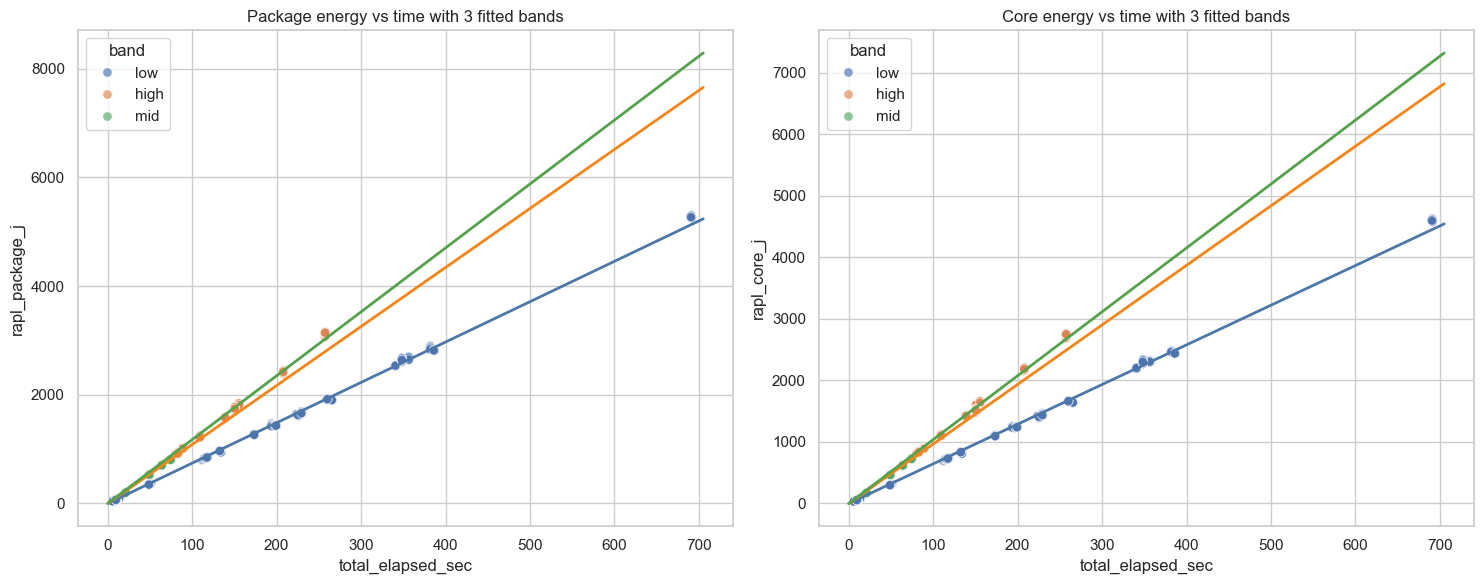

A/B summary: runtime and intensity differences (B vs A):


,query_family,elapsed_pct_B_vs_A,pkg_intensity_pct_B_vs_A,core_intensity_pct_B_vs_A
7,APX1278,-94.099468,-38.855201,-43.555974
6,APX1225,-77.593842,-29.608319,-31.485652
9,PE017,-61.849750,-3.921733,-4.713008
5,APX1186,-45.667381,55.089412,62.014753
3,APX1145,-26.684876,0.405466,0.252725
2,APX1130,-8.352330,-0.525530,-0.397525
8,PE002,-1.358146,-0.222791,-0.303751
10,PE019,-0.569581,0.376849,0.334142
1,APX1092,0.005236,0.667554,0.632370
0,APX1090,2.035454,0.185864,0.151648


A/B band membership (%):


band                   high    low   mid
query_family variant                    
APX1090      A          0.0  100.0   0.0
             B          0.0  100.0   0.0
APX1092      A        100.0    0.0   0.0
             B        100.0    0.0   0.0
APX1130      A          0.0  100.0   0.0
             B          0.0  100.0   0.0
APX1145      A        100.0    0.0   0.0
             B        100.0    0.0   0.0
APX1173      A          0.0  100.0   0.0
             B          0.0  100.0   0.0
APX1186      A          0.0  100.0   0.0
             B         25.0    0.0  75.0
APX1225      A         25.0    0.0  75.0
             B          0.0   75.0  25.0
APX1278      A         93.8    0.0   6.2
             B          0.0  100.0   0.0
PE002        A          0.0  100.0   0.0
             B          0.0  100.0   0.0
PE017        A          0.0  100.0   0.0
             B          0.0  100.0   0.0
PE019        A          3.1   75.0  21.9
             B         15.6   75.0   9.4

In [17]:
# Refined band analysis: cluster point-level energy intensity and compare A/B behavior
from sklearn.cluster import KMeans

bdf = edf_valid.copy()
parsed = bdf["test_name"].str.extract(r"^(.*)-query([AB])\.sql$")
bdf["query_family"] = parsed[0]
bdf["variant"] = parsed[1]

# Point-level intensity (J/s) explains the visual line bands in energy vs time scatter
bdf["pkg_j_per_sec"] = bdf["rapl_package_j"] / bdf["total_elapsed_sec"]
bdf["core_j_per_sec"] = bdf["rapl_core_j"] / bdf["total_elapsed_sec"]

feat = bdf[["pkg_j_per_sec", "core_j_per_sec"]].to_numpy()
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
bdf["band_id"] = kmeans.fit_predict(feat)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=["pkg_j_per_sec", "core_j_per_sec"])
centers["band_id"] = centers.index
centers = centers.sort_values("pkg_j_per_sec").reset_index(drop=True)
centers["band"] = ["low", "mid", "high"]
band_map = dict(zip(centers["band_id"], centers["band"]))
bdf["band"] = bdf["band_id"].map(band_map)

print("Band centers (typical energy intensity):")
display(centers[["band", "pkg_j_per_sec", "core_j_per_sec"]])

print("Band composition by query family (% of samples in each family):")
family_band = pd.crosstab(bdf["query_family"], bdf["band"], normalize="index") * 100
display(family_band.round(1))

# Build trend lines through origin for each band in original scatter space
def slope_through_origin(x, y):
    denom = np.sum(x * x)
    if denom == 0:
        return np.nan
    return np.sum(x * y) / denom

band_slopes = []
for band_name, g in bdf.groupby("band"):
    x = g["total_elapsed_sec"].to_numpy()
    pkg_slope = slope_through_origin(x, g["rapl_package_j"].to_numpy())
    core_slope = slope_through_origin(x, g["rapl_core_j"].to_numpy())
    band_slopes.append({
        "band": band_name,
        "pkg_slope_j_per_sec": pkg_slope,
        "core_slope_j_per_sec": core_slope,
        "n": len(g)
    })
band_slopes = pd.DataFrame(band_slopes).sort_values("pkg_slope_j_per_sec")

print("Band trend-line slopes in scatter space (y = slope * time):")
display(band_slopes)

# Plot: scatter with band coloring + fitted band lines
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=bdf, x="total_elapsed_sec", y="rapl_package_j", hue="band", alpha=0.65, s=45, ax=axes[0]
 )
sns.scatterplot(
    data=bdf, x="total_elapsed_sec", y="rapl_core_j", hue="band", alpha=0.65, s=45, ax=axes[1]
 )

x_grid = np.linspace(0, bdf["total_elapsed_sec"].max() * 1.02, 200)
palette = {"low": "#4C78A8", "mid": "#F58518", "high": "#54A24B"}
for _, r in band_slopes.iterrows():
    axes[0].plot(x_grid, r["pkg_slope_j_per_sec"] * x_grid, color=palette[r["band"]], linewidth=2)
    axes[1].plot(x_grid, r["core_slope_j_per_sec"] * x_grid, color=palette[r["band"]], linewidth=2)

axes[0].set_title("Package energy vs time with 3 fitted bands")
axes[0].set_xlabel("total_elapsed_sec")
axes[0].set_ylabel("rapl_package_j")
axes[1].set_title("Core energy vs time with 3 fitted bands")
axes[1].set_xlabel("total_elapsed_sec")
axes[1].set_ylabel("rapl_core_j")
plt.tight_layout()
plt.show()

# A/B comparison: where each variant sits by intensity and by band
ab_summary = (
    bdf.groupby(["query_family", "variant"])[
        ["total_elapsed_sec", "rapl_package_j", "rapl_core_j", "pkg_j_per_sec", "core_j_per_sec"]
    ]
    .mean()
    .reset_index()
 )

ab_wide = ab_summary.pivot(index="query_family", columns="variant")
ab_wide.columns = [f"{m}_{v}" for m, v in ab_wide.columns]
ab_wide = ab_wide.reset_index().dropna(subset=["total_elapsed_sec_A", "total_elapsed_sec_B"]).copy()

ab_wide["elapsed_pct_B_vs_A"] = 100 * (ab_wide["total_elapsed_sec_B"] - ab_wide["total_elapsed_sec_A"]) / ab_wide["total_elapsed_sec_A"]
ab_wide["pkg_intensity_pct_B_vs_A"] = 100 * (ab_wide["pkg_j_per_sec_B"] - ab_wide["pkg_j_per_sec_A"]) / ab_wide["pkg_j_per_sec_A"]
ab_wide["core_intensity_pct_B_vs_A"] = 100 * (ab_wide["core_j_per_sec_B"] - ab_wide["core_j_per_sec_A"]) / ab_wide["core_j_per_sec_A"]

print("A/B summary: runtime and intensity differences (B vs A):")
display(
    ab_wide[[
        "query_family",
        "elapsed_pct_B_vs_A",
        "pkg_intensity_pct_B_vs_A",
        "core_intensity_pct_B_vs_A"
    ]].sort_values("elapsed_pct_B_vs_A")
)

variant_band = pd.crosstab([bdf["query_family"], bdf["variant"]], bdf["band"], normalize="index") * 100
print("A/B band membership (%):")
display(variant_band.round(1))

In [18]:
# Statistical testing for A/B query variants by query family
from scipy.stats import ttest_ind, shapiro, levene, mannwhitneyu

sdf = edf_valid.copy()
parsed = sdf["test_name"].str.extract(r"^(.*)-query([AB])\.sql$")
sdf["query_family"] = parsed[0]
sdf["variant"] = parsed[1]

# Add normalized metrics to control for runtime
sdf["pkg_j_per_sec"] = sdf["rapl_package_j"] / sdf["total_elapsed_sec"]
sdf["core_j_per_sec"] = sdf["rapl_core_j"] / sdf["total_elapsed_sec"]

metrics = [
    "total_elapsed_sec",
    "rapl_package_j",
    "rapl_core_j",
    "pkg_j_per_sec",
    "core_j_per_sec",
]

rows = []
for family, g in sdf.groupby("query_family"):
    a = g[g["variant"] == "A"]
    b = g[g["variant"] == "B"]
    if len(a) == 0 or len(b) == 0:
        continue

    for metric in metrics:
        x = a[metric].dropna().to_numpy()
        y = b[metric].dropna().to_numpy()
        n_a = len(x)
        n_b = len(y)
        if n_a < 2 or n_b < 2:
            continue

        shapiro_p_a = shapiro(x).pvalue if n_a >= 3 else np.nan
        shapiro_p_b = shapiro(y).pvalue if n_b >= 3 else np.nan
        normal_a = bool(shapiro_p_a > 0.05) if n_a >= 3 else False
        normal_b = bool(shapiro_p_b > 0.05) if n_b >= 3 else False

        levene_p = levene(x, y, center="median").pvalue

        # Similar logic to your Assignment 1 flow: if both groups look normal, use t-test; otherwise Mann-Whitney U.
        if normal_a and normal_b:
            test_name = "welch_ttest"
            p_value = ttest_ind(x, y, equal_var=False).pvalue
            pooled_sd = np.sqrt(((n_a - 1) * np.var(x, ddof=1) + (n_b - 1) * np.var(y, ddof=1)) / (n_a + n_b - 2))
            effect_size = (np.mean(x) - np.mean(y)) / pooled_sd if pooled_sd > 0 else np.nan
            effect_label = "cohens_d_A_minus_B"
        else:
            test_name = "mannwhitney_u"
            u_stat = mannwhitneyu(x, y, alternative="two-sided").statistic
            p_value = mannwhitneyu(x, y, alternative="two-sided").pvalue
            effect_size = (2 * u_stat / (n_a * n_b)) - 1
            effect_label = "rank_biserial_A_minus_B"

        rows.append({
            "query_family": family,
            "metric": metric,
            "n_A": n_a,
            "n_B": n_b,
            "A_mean": np.mean(x),
            "B_mean": np.mean(y),
            "A_median": np.median(x),
            "B_median": np.median(y),
            "A_minus_B_mean": np.mean(x) - np.mean(y),
            "A_minus_B_median": np.median(x) - np.median(y),
            "A_vs_B_mean_pct": 100 * (np.mean(x) - np.mean(y)) / np.mean(y) if np.mean(y) != 0 else np.nan,
            "shapiro_p_A": shapiro_p_a,
            "shapiro_p_B": shapiro_p_b,
            "levene_p": levene_p,
            "test_used": test_name,
            "p_value": p_value,
            "effect_label": effect_label,
            "effect_size": effect_size
        })

results = pd.DataFrame(rows)
results["significant_0_05"] = results["p_value"] < 0.05

print("Normality check + A/B hypothesis test results per query family and metric:")
display(
    results.sort_values(["metric", "query_family"])[
        [
            "query_family", "metric", "n_A", "n_B",
            "shapiro_p_A", "shapiro_p_B", "levene_p",
            "test_used", "p_value", "significant_0_05",
            "A_mean", "B_mean", "A_vs_B_mean_pct",
            "effect_label", "effect_size"
        ]
    ]
)

print("Significant differences (p < 0.05):")
display(
    results.loc[results["significant_0_05"]].sort_values(["metric", "p_value"])[
        [
            "query_family", "metric", "test_used", "p_value",
            "A_mean", "B_mean", "A_vs_B_mean_pct", "effect_label", "effect_size"
        ]
    ]
)

Normality check + A/B hypothesis test results per query family and metric:


,query_family,metric,n_A,n_B,shapiro_p_A,shapiro_p_B,levene_p,test_used,p_value,significant_0_05,A_mean,B_mean,A_vs_B_mean_pct,effect_label,effect_size
4,APX1090,core_j_per_sec,34,34,4.354990e-01,1.645939e-02,0.199554,mannwhitney_u,9.364551e-01,False,6.264781,6.274282,-0.151418,rank_biserial_A_minus_B,-0.012111
9,APX1092,core_j_per_sec,32,32,8.300734e-04,1.001677e-06,0.696599,mannwhitney_u,2.574914e-03,True,10.244285,10.309067,-0.628396,rank_biserial_A_minus_B,-0.439453
14,APX1130,core_j_per_sec,31,31,1.110095e-02,2.846115e-01,0.231578,mannwhitney_u,6.721786e-02,False,6.416187,6.390681,0.399111,rank_biserial_A_minus_B,0.271592
19,APX1145,core_j_per_sec,32,32,1.443670e-03,5.993710e-07,0.484299,mannwhitney_u,1.997398e-01,False,10.281362,10.307346,-0.252088,rank_biserial_A_minus_B,0.187500
24,APX1173,core_j_per_sec,32,31,5.532974e-05,2.234199e-01,0.008792,mannwhitney_u,4.918422e-04,True,6.335134,6.267435,1.080160,rank_biserial_A_minus_B,0.512097
29,APX1186,core_j_per_sec,32,32,1.500129e-03,3.854424e-06,0.005214,mannwhitney_u,6.511314e-12,True,6.113785,9.905234,-38.277226,rank_biserial_A_minus_B,-1.000000
34,APX1225,core_j_per_sec,32,32,4.911538e-08,5.737135e-08,0.011069,mannwhitney_u,6.511314e-12,True,9.575189,6.560378,45.954831,rank_biserial_A_minus_B,1.000000
39,APX1278,core_j_per_sec,32,33,4.474495e-04,8.343866e-05,0.255797,mannwhitney_u,4.464370e-12,True,10.238175,5.778838,77.166668,rank_biserial_A_minus_B,1.000000
44,PE002,core_j_per_sec,32,32,3.712918e-07,1.101378e-07,0.686338,mannwhitney_u,1.426756e-02,True,5.861690,5.843885,0.304676,rank_biserial_A_minus_B,0.357422
49,PE017,core_j_per_sec,32,31,1.884563e-02,7.569652e-03,0.920851,mannwhitney_u,9.610615e-12,True,6.596351,6.285464,4.946119,rank_biserial_A_minus_B,1.000000


Significant differences (p < 0.05):


,query_family,metric,test_used,p_value,A_mean,B_mean,A_vs_B_mean_pct,effect_label,effect_size
39,APX1278,core_j_per_sec,mannwhitney_u,4.464370e-12,10.238175,5.778838,77.166668,rank_biserial_A_minus_B,1.000000
29,APX1186,core_j_per_sec,mannwhitney_u,6.511314e-12,6.113785,9.905234,-38.277226,rank_biserial_A_minus_B,-1.000000
34,APX1225,core_j_per_sec,mannwhitney_u,6.511314e-12,9.575189,6.560378,45.954831,rank_biserial_A_minus_B,1.000000
49,PE017,core_j_per_sec,mannwhitney_u,9.610615e-12,6.596351,6.285464,4.946119,rank_biserial_A_minus_B,1.000000
24,APX1173,core_j_per_sec,mannwhitney_u,4.918422e-04,6.335134,6.267435,1.080160,rank_biserial_A_minus_B,0.512097
9,APX1092,core_j_per_sec,mannwhitney_u,2.574914e-03,10.244285,10.309067,-0.628396,rank_biserial_A_minus_B,-0.439453
44,PE002,core_j_per_sec,mannwhitney_u,1.426756e-02,5.861690,5.843885,0.304676,rank_biserial_A_minus_B,0.357422
38,APX1278,pkg_j_per_sec,mannwhitney_u,4.464370e-12,11.348814,6.939210,63.546209,rank_biserial_A_minus_B,1.000000
28,APX1186,pkg_j_per_sec,mannwhitney_u,6.511314e-12,7.099165,11.010053,-35.521066,rank_biserial_A_minus_B,-1.000000
33,APX1225,pkg_j_per_sec,mannwhitney_u,6.511314e-12,10.918049,7.685398,42.062241,rank_biserial_A_minus_B,1.000000


In [19]:
# Compact text summary of significant A/B results
sig = results[results["significant_0_05"]].copy()
print(f"Total tests run: {len(results)}")
print(f"Significant tests (p < 0.05): {len(sig)}")

if len(sig) > 0:
    show_cols = [
        "query_family", "metric", "test_used", "p_value",
        "A_mean", "B_mean", "A_vs_B_mean_pct", "effect_label", "effect_size"
    ]
    print(sig.sort_values(["metric", "p_value"])[show_cols].to_string(index=False))
else:
    print("No statistically significant A/B differences at p < 0.05.")

Total tests run: 55
Significant tests (p < 0.05): 41
query_family            metric     test_used      p_value      A_mean      B_mean  A_vs_B_mean_pct            effect_label  effect_size
     APX1278    core_j_per_sec mannwhitney_u 4.464370e-12   10.238175    5.778838        77.166668 rank_biserial_A_minus_B     1.000000
     APX1186    core_j_per_sec mannwhitney_u 6.511314e-12    6.113785    9.905234       -38.277226 rank_biserial_A_minus_B    -1.000000
     APX1225    core_j_per_sec mannwhitney_u 6.511314e-12    9.575189    6.560378        45.954831 rank_biserial_A_minus_B     1.000000
       PE017    core_j_per_sec mannwhitney_u 9.610615e-12    6.596351    6.285464         4.946119 rank_biserial_A_minus_B     1.000000
     APX1173    core_j_per_sec mannwhitney_u 4.918422e-04    6.335134    6.267435         1.080160 rank_biserial_A_minus_B     0.512097
     APX1092    core_j_per_sec mannwhitney_u 2.574914e-03   10.244285   10.309067        -0.628396 rank_biserial_A_minus_B    -0.43